# Behavioural Classifier Execution
**Goal:** 
To test our new standalone `BehaviouralClassifier` module across the market dataset. 

This notebook loads the historical price data, chops it into current 26-day blocks, and passes them through our strict, target-relative mathematical rules to assign them to our exact trading groups.


In [1]:

import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import os, glob
from behavioural_classifier import BehaviouralClassifier

# 1. Initialize our new Engine
# We are hunting for a 5% target within 13 days
classifier = BehaviouralClassifier(target_pct=5.0, target_days=13, regime_lookback=26)

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:150]  # Let's scan 150 stocks

# 2. Run the Engine on the most recent 26-day block of each stock
results = []

for file_path in all_files:
    try:
        df = pd.read_csv(file_path)
        if len(df) < 100: continue
        
        # We only pass the most recent 100 days of data to the classifier
        # (It needs some runway to calculate moving averages)
        recent_data = df.iloc[-100:].copy()
        
        stock_name = os.path.basename(file_path).split('.')[0]
        
        # The engine mathematically classifies the block
        group_label, metrics = classifier.classify_block(recent_data)
        
        results.append({
            'Stock': stock_name,
            'Group': group_label,
            'Hit_Rate': metrics.get('Hit_Rate', None),
            'Volatility': metrics.get('Daily_Volatility', None)
        })
    except Exception as e:
        pass

df_results = pd.DataFrame(results)

# 3. Show how many stocks fell into each mathematically defined group
print("MARKET CLASSIFICATION RESULTS:")
print("=" * 50)
print(df_results['Group'].value_counts())
print("\n")
display(df_results[df_results['Group'].str.startswith('GROUP')].head(10))


MARKET CLASSIFICATION RESULTS:
Group
BLACKLIST_UNFAVORABLE         113
BLACKLIST_NO_TREND             21
GROUP_3_SAFE_GRINDER           10
GROUP_2_AGGRESSIVE_CLIMBER      5
GROUP_1_HOLY_GRAIL              1
Name: count, dtype: int64




,Stock,Group,Hit_Rate,Volatility
1,3MINDIA,GROUP_3_SAFE_GRINDER,26.9,1.55
4,AARTIIND,GROUP_3_SAFE_GRINDER,15.4,1.91
7,ABB,GROUP_3_SAFE_GRINDER,35.0,2.00
20,ADANIENSOL,GROUP_3_SAFE_GRINDER,34.6,1.74
28,AETHER,GROUP_2_AGGRESSIVE_CLIMBER,42.3,2.93
41,AKUMS,GROUP_2_AGGRESSIVE_CLIMBER,42.3,2.09
51,ANANDRATHI,GROUP_3_SAFE_GRINDER,23.1,1.41
63,APLLTD,GROUP_3_SAFE_GRINDER,19.2,1.80
65,APOLLOPIPE,GROUP_3_SAFE_GRINDER,19.0,1.58
69,ARKADE,GROUP_2_AGGRESSIVE_CLIMBER,42.3,2.37


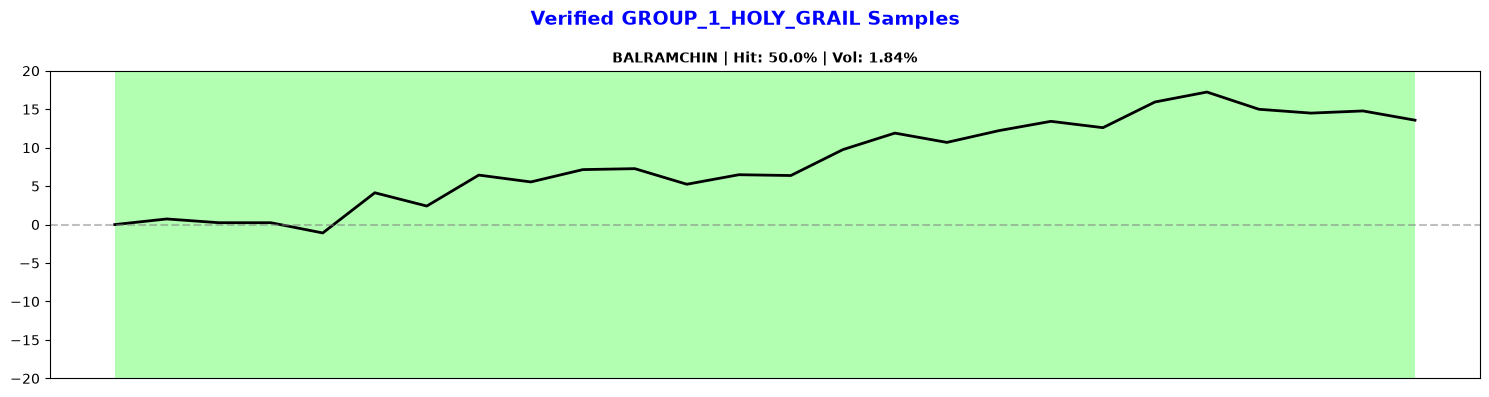

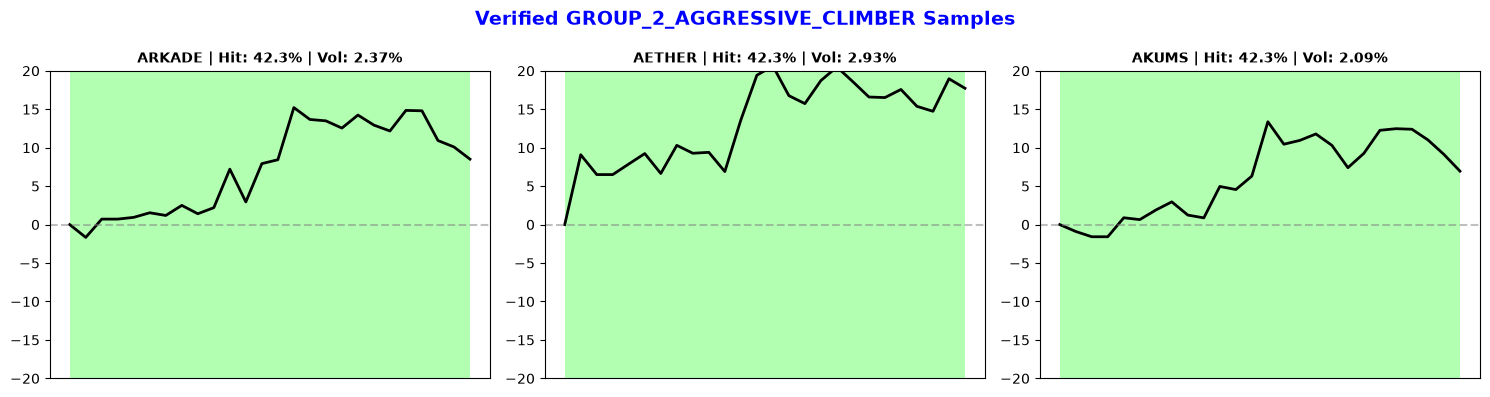

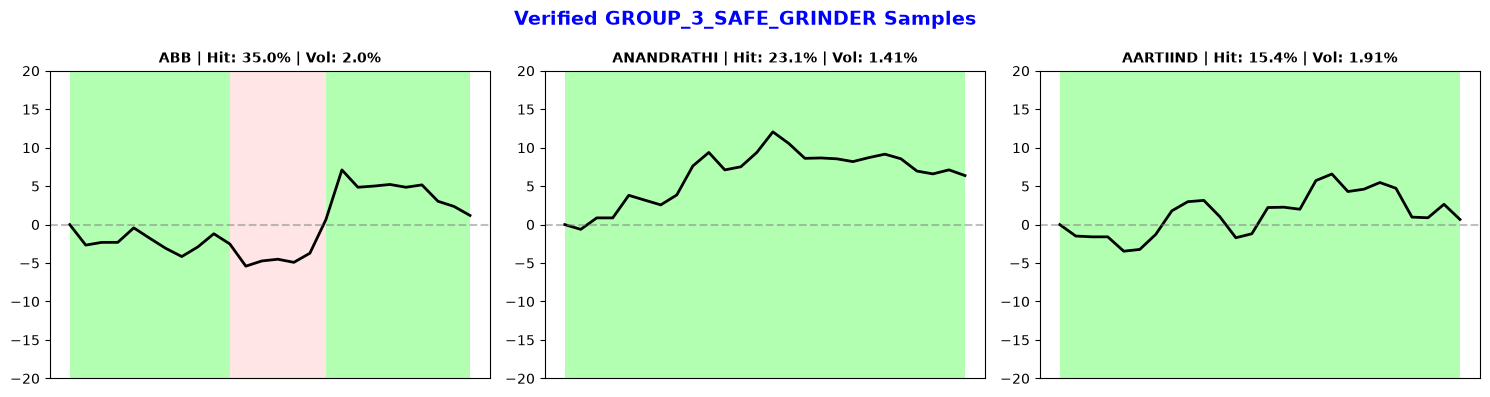

In [2]:

# 4. Plot 3 random stocks from each Actionable Group to verify visually
actionable_groups = ['GROUP_1_HOLY_GRAIL', 'GROUP_2_AGGRESSIVE_CLIMBER', 'GROUP_3_SAFE_GRINDER']

for group in actionable_groups:
    group_stocks = df_results[df_results['Group'] == group]
    
    if len(group_stocks) == 0:
        print(f"No stocks found in {group}")
        continue
        
    samples = group_stocks.sample(min(3, len(group_stocks)))
    
    fig, axes = plt.subplots(1, len(samples), figsize=(15, 4))
    if len(samples) == 1: axes = [axes]
    
    fig.suptitle(f"Verified {group} Samples", fontsize=14, weight='bold', color='blue')
    
    for i, (_, row) in enumerate(samples.iterrows()):
        stock = row['Stock']
        file_path = os.path.join(DATA_DIR, f"{stock}.csv")
        df = pd.read_csv(file_path).iloc[-26:].copy() # The actual 26-day block
        
        # Normalize to % change
        start_price = df['Close'].iloc[0]
        block_pct = ((df['Close'] / start_price) - 1) * 100
        
        axes[i].plot(range(len(block_pct)), block_pct, color='black', lw=2)
        axes[i].axhline(0, color='gray', linestyle='--', alpha=0.5)
        
        # Shade UP regime
        st_trend = classifier.calc_supertrend(pd.read_csv(file_path).iloc[-100:])[-26:]
        for j in range(1, len(df)):
            if st_trend[j] == 1:
                axes[i].axvspan(j-1, j, color='lime', alpha=0.3, lw=0)
            else:
                axes[i].axvspan(j-1, j, color='red', alpha=0.1, lw=0)
                
        axes[i].set_title(f"{stock} | Hit: {row['Hit_Rate']}% | Vol: {row['Volatility']}%", fontsize=10, weight='bold')
        axes[i].set_ylim(-20, 20)
        axes[i].set_xticks([])
        
    plt.tight_layout()
    plt.show()
